#Regularisation and Optimisation
This assignment investigates training of CNNs on CIFAR with a goal of maximising accuracy.

Brian Howard - 24349968

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) is a dataset with small size (32x32) images and 50k training samsamples.
* It is often used as a "Hello World" type data set to setup a training pipeline. As it is relatively fast to train a network with CIFAR-10, this dataset is also widely used for running comparison or optimisation experiments. For example comparing different networks, regularisation methods or optimisers. (In pytorch the CIFAR-10 dataset is available as a [pytorch dataset](https://pytorch.org/vision/0.18/generated/torchvision.datasets.CIFAR10.html) simplifying loading the dataset.)

The starting point in this assignment is an untrained convolutional neural network.
* You will not modify the structure of the network. (We will discuss network structures in more detail in section 2 of module).
* The network has sufficient capacity (Parameters/FLOPS) to achieve high accuracy.
* The notebook (starting configurataion) will train the model without regularisation and using the SGD optimiser. From inspection of the training/validation accuracy/loss, it will be observed that the network is ovefitting.
* You will improve the performance of the network using regularisation techniques (See below).
* The goal is to use one or several techniques to prevent overfitting and maximse test accuracy.

Regularisation techniques.
* [Data Augmentation using pytorch transforms](https://pytorch.org/vision/0.15/transforms.html)
* Regularisation layers such as [dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) and [batch normalisation](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html).

The learning rate also acts as a regulariser, with large learning rates having a regularising effect. You may also include a LR schedule as detailed in the [pytorch optim package](https://pytorch.org/docs/stable/optim.html). The optim package contains several implementations of LR schedules including those detailed in the papers:
* [Cyclical Learning Rates for Training Neural Networks](https://arxiv.org/pdf/1506.01186)
* [Super-Convergence: Very Fast Training of Neural
Networks Using Large Learning Rates](https://arxiv.org/pdf/1708.07120)


How to approach this Assignment.
* There are a lot things to try and possible approaches. Keep a table of what you have tried. Apart from recording training and test accuracy, Ensure that you record the key hyperparameters, including optimiser, base learning rate, number of epochs for each run. This makes repeating experiments possible if you want to try a variation.
* Your final submitted notebook should include your best attempt showing training curves and a comment on your approach. (Do not submit a notebook with multiple approaches)


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models
from torchvision.transforms import ToTensor, v2, Pad
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!pip install torchinfo

## Import Dataset
The [torchvision](https://pytorch.org/vision/stable/index.html) package (imported above) makes available several common image classification, object detection, semantic segmentation datasets, aswell as other [datasets](https://pytorch.org/vision/stable/datasets.html) for common computer vision applications.  

Torchvision supports common computer vision transformations in the torchvision.transforms and torchvision.transforms.v2 modules. Transforms can be used to transform or augment data for training or inference of different tasks (image classification, detection, segmentation, video classification). You can adjust these transforms as part of your regularisation strategy for the network. (Note that only the train_transform should be modified, we don't want to apply augmentation to the test set)

In [3]:


train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(10),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToDtype(torch.float32, scale=True),
    ToTensor(),
    v2.Normalize([0.4915, 0.4822, 0.4466], [0.2470, 0.2435, 0.2616]),
])


test_transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    ToTensor(),
    v2.Normalize([0.4915, 0.4822, 0.4466], [0.2470, 0.2435, 0.2616]),
])


In [4]:
# Download training data from open datasets.
training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transforms,
)

# Download test data from open datasets.
test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transforms,
)

The `Dataset` is passed as an argument to `DataLoader`. This wraps an
iterable over the dataset, and supports automatic batching, sampling,
shuffling and multiprocess data loading.

In [5]:
batch_size = 128

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([128, 3, 32, 32])
Shape of y: torch.Size([128]) torch.int64


In [6]:
print('Test Samples ',len(test_dataloader.dataset))
print('Train Samples ',len(train_dataloader.dataset))
print('Test Batches ',len(test_dataloader))
print('Train Batches ',len(train_dataloader))

Test Samples  10000
Train Samples  50000
Test Batches  79
Train Batches  391


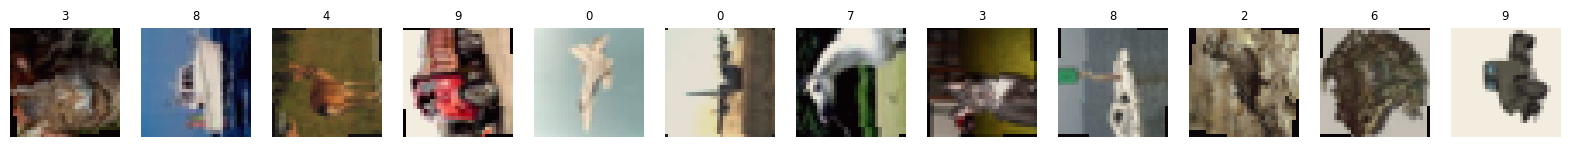

In [7]:
# Output next batch from dataloader
dataiter = iter(train_dataloader)
image_batch, labels_batch = next(dataiter)

# Use matplotlib to plot a sample of images

i=0
n_plots = 12 # number of plots
f, axarr = plt.subplots(1,n_plots,figsize=(20,10))

for image in image_batch[0:n_plots,:,:,:]:
  disp_image =  torch.permute(image,(2,1,0)).numpy() # return image to cpu for display and permute to channels last
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  disp_image = std * disp_image + mean
  disp_image = np.clip(disp_image, 0, 1)
  axarr[i].imshow(disp_image[:,:,:])
  axarr[i].axis("off")
  axarr[i].set_title(labels_batch[i].numpy(),fontsize='small')
  i = i+1

# Define CNN Model

To define a neural network in PyTorch, we create a class that inherits ([see python inheritance](https://www.w3schools.com/python/python_inheritance.asp))
from
[nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html).
We define the layers of the network in the `__init__` function and
specify how data will pass through the network in the `forward`
function. To accelerate operations in the neural network, we move it to
the GPU.

A simple CNN is defined using [2D convolution](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [2D max pooling layers](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html). [Relu activiation](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) is applied after the convolution layers. The output of the last convolution is [flattened](https://pytorch.org/docs/stable/generated/torch.flatten.html) and [2 linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) (dense) layers applied. Only activiation is applied after the first linear layer. As seen in the next section when setting up our loss function we use the form `_from_logits` so the optimiser will know that softmax activiation needs to be applied. (Alternatively we can directly apply [softmax activiation](https://pytorch.org/docs/stable/generated/torch.nn.functional.softmax.html))

* **You do not need to modify the network architecture**. You can add regularisation layers and adjust the optimisation/learning rate schedule which is a further method of regularisation in later code cells.

In [8]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")


Using cuda device


In [9]:


class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.simple_cnn = nn.Sequential(
            nn.Conv2d(3,32,3,padding='same'),
            nn.ReLU(),
            nn.Conv2d(32,64,3,padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(p=0.1),

            nn.Conv2d(64,64,3,padding='same'),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(p=0.1),

            nn.Conv2d(64,128,3,padding='same'),
            nn.ReLU(),
            nn.Conv2d(128,256,3,padding='same'),
            nn.ReLU(),
            nn.Conv2d(256,256,3,padding='same'),
            nn.MaxPool2d(2),
            nn.Dropout(p=0.1),

            nn.Flatten(),
            nn.Linear(256*4*4, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):

        logits = self.simple_cnn(x)
        return logits

# Allocate network to device
model = NeuralNetwork().to(device)



In [10]:
from torchinfo import summary
# Ensure input size is correct
summary(model, input_size=(batch_size, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [128, 10]                 --
├─Sequential: 1-1                        [128, 10]                 --
│    └─Conv2d: 2-1                       [128, 32, 32, 32]         896
│    └─ReLU: 2-2                         [128, 32, 32, 32]         --
│    └─Conv2d: 2-3                       [128, 64, 32, 32]         18,496
│    └─ReLU: 2-4                         [128, 64, 32, 32]         --
│    └─MaxPool2d: 2-5                    [128, 64, 16, 16]         --
│    └─Dropout: 2-6                      [128, 64, 16, 16]         --
│    └─Conv2d: 2-7                       [128, 64, 16, 16]         36,928
│    └─ReLU: 2-8                         [128, 64, 16, 16]         --
│    └─Conv2d: 2-9                       [128, 64, 16, 16]         36,928
│    └─ReLU: 2-10                        [128, 64, 16, 16]         --
│    └─MaxPool2d: 2-11                   [128, 64, 8, 8]           --
│ 

# Optimisation & Training Loop

For this classification problem we will use the  [CrossEntropy loss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). In this pytorch function, the input is the un-normalised logit value.

* The SGD (Stocasitc Gradient Descent) Optimiser is provided as a the default training configuration. As the learning rate is fixed, this may not be optimal as training progresses for finding the global minimum.

* Note that you can interrupt the training if it has converged (or failed) and then view the tensorboard curves and also obtain accuracy of the test set (by running the appropriate cells).

* Make sure to run the model call and optimiser call before starting training again to ensure the previous training state is cleared.

[Tensorboard is imported](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) to display results.


In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)

# add the schedulers
# per epoch scheduler to try
#scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60], gamma=0.1)

# iteration scheduler to try
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.05, steps_per_epoch=len(train_dataloader), epochs=20,pct_start=0.3,anneal_strategy='cos')


Initialise Tensorboard (use of tensorboard in colab notebooks is [detailed here](https://colab.research.google.com/github/tensorflow/tensorboard/blob/master/docs/tensorboard_in_notebooks.ipynb))


In [12]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs')

Training & Validataion Loop

In [13]:

n_iter =100   # Set how frequently will return loss (must be less than test_size)
n_epochs = 20 # Set total number of epochs
train_size = len(train_dataloader.dataset)
test_size = len(test_dataloader.dataset)
num_test_batches = len(test_dataloader)

for epoch in range(n_epochs):  # loop over the dataset multiple times
    running_loss = 0.0
    running_acc = 0.0

    for i, data in enumerate(train_dataloader, 0):
        # basic training loop
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # this one is within the iteration scheduler
        scheduler.step()

        running_loss += loss.item()
        running_acc += (outputs.argmax(1) == labels).type(torch.float).sum().item()
        if i % n_iter == n_iter-1:    # Every n mini-batches...
            print('Epoch {}'.format(epoch),' Batch {}'.format(i + 1))
            # Check against the validation set
            running_vloss = 0.0
            running_vacc = 0.0
            # In evaluation mode some model specific operations can be omitted eg. dropout layer
            model.train(False) # Switching to evaluation mode, eg. turning off regularisation
            for j, vdata in enumerate(test_dataloader, 0):

                vinputs, vlabels = vdata
                vinputs, vlabels = vinputs.to(device), vlabels.to(device)
                voutputs = model(vinputs)
                vloss = loss_fn(voutputs, vlabels)
                running_vloss += vloss.item()
                running_vacc += (voutputs.argmax(1) == vlabels).type(torch.float).sum().item()
            model.train(True) # Switching back to training mode, eg. turning on regularisation

            avg_loss = running_loss / n_iter  # Compute loss over n_iter iterations
            avg_acc = 100*running_acc / (n_iter*batch_size) # number of examples computing accuracy over
            avg_vloss = running_vloss / num_test_batches
            avg_vacc = 100*running_vacc / test_size
            running_loss = 0.0
            running_acc = 0.0
            # Print intermediate results
            print(f"Training Error: \n Accuracy: {(avg_acc):>0.1f}%, Avg loss: {avg_loss:>8f} \n")
            print(f"Test Error: \n Accuracy: {(avg_vacc):>0.1f}%, Avg loss: {avg_vloss:>8f} \n")

            # Log the running loss averaged per batch
            writer.add_scalars('Loss',
                            { 'Training Loss' : avg_loss, 'Validation Loss' : avg_vloss },
                            epoch * len(train_dataloader) + i)
            writer.add_scalars('Accuracy',
                            {'Training Acc' : avg_acc, 'Validation Acc' : avg_vacc },
                            epoch * len(train_dataloader) + i)

    # this one is within the per epoch scheduler
    # scheduler.step()


print('Finished Training')

writer.flush()

Epoch 0  Batch 100
Training Error: 
 Accuracy: 10.2%, Avg loss: 2.302610 

Test Error: 
 Accuracy: 10.0%, Avg loss: 2.302602 

Epoch 0  Batch 200
Training Error: 
 Accuracy: 10.5%, Avg loss: 2.302635 

Test Error: 
 Accuracy: 10.9%, Avg loss: 2.302269 

Epoch 0  Batch 300
Training Error: 
 Accuracy: 11.1%, Avg loss: 2.302228 

Test Error: 
 Accuracy: 10.0%, Avg loss: 2.301657 

Epoch 1  Batch 100
Training Error: 
 Accuracy: 16.6%, Avg loss: 2.238638 

Test Error: 
 Accuracy: 24.0%, Avg loss: 2.107644 

Epoch 1  Batch 200
Training Error: 
 Accuracy: 24.1%, Avg loss: 2.062875 

Test Error: 
 Accuracy: 26.8%, Avg loss: 1.955208 

Epoch 1  Batch 300
Training Error: 
 Accuracy: 27.8%, Avg loss: 1.936740 

Test Error: 
 Accuracy: 32.5%, Avg loss: 1.798043 

Epoch 2  Batch 100
Training Error: 
 Accuracy: 35.6%, Avg loss: 1.722171 

Test Error: 
 Accuracy: 40.7%, Avg loss: 1.610555 

Epoch 2  Batch 200
Training Error: 
 Accuracy: 41.2%, Avg loss: 1.622647 

Test Error: 
 Accuracy: 46.4%, Avg l

Note when r[unning colab container on docker, tensorboard](https://leimao.github.io/blog/TensorBoard-On-Docker/) will open on webpage: http://127.0.0.1:6006/

In [14]:
#%load_ext tensorboard
#%reload_ext tensorboard
#%tensorboard --logdir runs --bind_all

# Evaluate Model
We will obtain the classification report after final evaluation of the test dataset with the model. A confusion matrix can also be obtained and we will plot a few example images.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

store_predictions = []
store_labels = []
model.eval()

for i, data in enumerate(test_dataloader, 0):
    # basic training loop
    input_batch, label_batch = data
    input_batch = input_batch.to(device)

    pred_logit = model(input_batch)
    predictions = torch.argmax(pred_logit,1) # reduce along output dimension
    predictions_np = predictions.to("cpu").numpy()
    label_batch_np = label_batch.numpy()
    if i<num_test_batches-1:
      store_predictions.append(predictions_np)
      store_labels.append(label_batch)

y_pred = np.squeeze(np.reshape(store_predictions,(1,(num_test_batches-1)*batch_size)))
y_true = np.squeeze(np.reshape(store_labels,(1,(num_test_batches-1)*batch_size)))

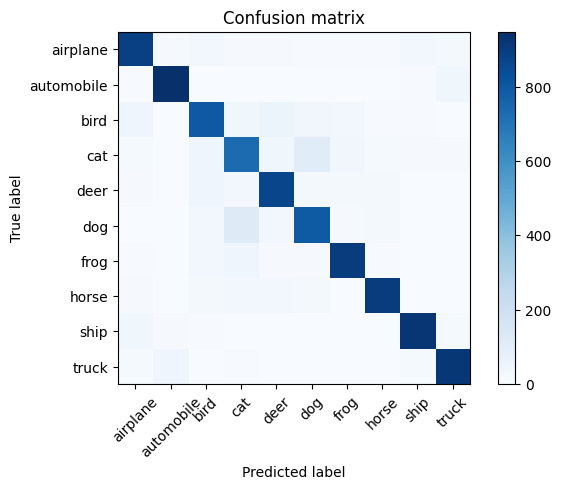

In [16]:
#https://scikit-learn.org/0.16/auto_examples/model_selection/plot_confusion_matrix.html
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

plot_confusion_matrix(cm)

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

    airplane       0.87      0.89      0.88       998
  automobile       0.94      0.95      0.94       999
        bird       0.81      0.80      0.80       999
         cat       0.73      0.73      0.73       997
        deer       0.84      0.87      0.85      1000
         dog       0.80      0.79      0.80       997
        frog       0.91      0.90      0.90      1000
       horse       0.92      0.90      0.91       997
        ship       0.93      0.93      0.93       997
       truck       0.92      0.92      0.92      1000

    accuracy                           0.87      9984
   macro avg       0.87      0.87      0.87      9984
weighted avg       0.87      0.87      0.87      9984



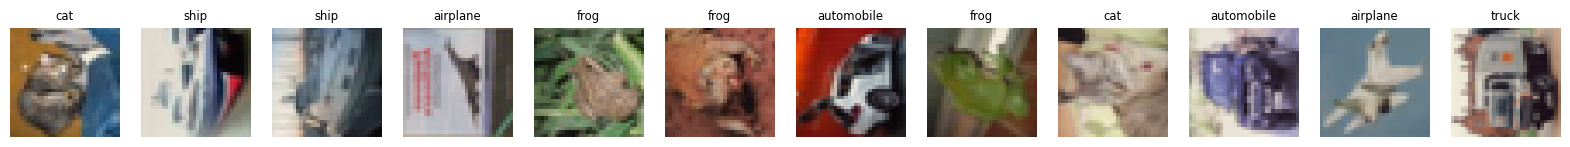

In [18]:
# Output next batch from dataloader
dataiter = iter(test_dataloader)
image_batch, labels_batch = next(dataiter)

# Pass batch through model
model.eval()
image_batch = image_batch.to(device)
pred_logit = model(image_batch)


# Use matplotlib to plot a sample of images
import matplotlib.pyplot as plt
i=0
n_plots = 12 # number of plots
f, axarr = plt.subplots(1,n_plots,figsize=(20,10))


for image in image_batch[0:n_plots,:,:,:]:
  disp_image =  torch.permute(image.to('cpu'),(2,1,0)).numpy() # return image to cpu for display and permute to channels last
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  disp_image = std * disp_image + mean
  disp_image = np.clip(disp_image, 0, 1)
  axarr[i].imshow(disp_image[:,:,:])
  axarr[i].axis("off")
  predicted, actual = classes[pred_logit[i,:].argmax(0)], classes[labels_batch[i]]
  color = 'black' if predicted == actual else 'red'
  axarr[i].set_title(predicted,fontsize='small', color=color)
  i = i+1

 # Comments about your Approach

Notes 1: <br/>
First step in this was to get everything installed and running. So far so good noting the training cycle is quite time consuming so will need to research before hand what the best options could be for this type of data set so im not randomly choosing optimizations and regularization approaches that do not make sense for image classification tasks. <br/>


Keeping track of the initial baseline here. <br/>
<hr>
Epoch 10  Batch 300 <br/>
Training Error: <br/>
 Accuracy: 89.6%, Avg loss: 0.290788 <br/>
Test Error: <br/>
 Accuracy: 77.0%, Avg loss: 0.758272 <br/>
<hr>



Notes 2:  <br/>
Taking my lead from the PyTorch Docs and starting with https://docs.pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate and i am chaining schedulers. Along with the schedulers I think some data augmentation could be helpful in improving generalization. <br/>

Just noting I was reading up on my GPUand its a Radeon so not supported by PyTorch which could explain some of the slow training time. <br/>




Notes 3:  <br>
Adding the data augmentation to the dataloader and noticed a better generalization. Using colab now not my local machine for running this notebook sped up the time to train massively as per suggestion from the forum.
I found some cominations of data augmentations dont work well together and need to be mindful of the data shape/size when flipping. Got a better understanding of OneCycleLR and MultiStepLR multi step is better per epoch and OneCycle is better for per iteration.

| Run | Optimizer       | Learning Rate | Epochs | Batch Size | Train Accuracy (%) | Test Accuracy (%) | Conclusion |
|-----|----------------|---------------|--------|------------|------------------|-----------------|------------------|
| 1   | SGD             | 0.01          | 10     | 128        | 89.6%             | 77%            | Overfitting as shown by the gap between training and test data    |
| 2   | SGD + MultiStepLR Scheduler | 0.01           | 10     | 128        | 86.2%            | 75%            |                 |    
| 3   | SGD + MultiStepLR Scheduler + data augmentation | 0.01           | 20     | 128        | 76%             | 76%            | Better generalisation after augmentation but need to improve overall accuarcy, increased epochs to 20 |    
| 4   | SGD + OneCycleLR Scheduler + data augmentation | 0.01           | 20     | 128        | 96.8%             | 86.8%            | Using the OneCycleLR with per iteration                 |    
| 5   | SGD + OneCycleLR Scheduler + data augmentation + Normalisation adjustemnts | 0.01           | 20     | 128        | 97%             | 86.7%            | Using the values calculated for mean and std from slides for  QA session 2 |    
| 6   | SGD + OneCycleLR Scheduler + data augmentation + Normalisation adjustemnts + dropout layers | 0.01           | 20     | 128        | 91.1%             | 86.7%            | Added dropout layers to help with overfitting |  


